# APR Workflow


### This Notebook's Operations

This workflow starts from `FILENAME_INPUT`, creates a calibrated source file, then appends APR results into the same output file.

1. `FILENAME_INPUT` -> calibration -> `FILENAME_OUTPUT`
2. `FILENAME_OUTPUT` -> `apr` with `mode="append"` -> `FILENAME_OUTPUT`

The exported file contains the APR output under `/output`. The default output key is the summed APR decay at `/output/{run_id}/products/apr_sum`; the all-channel reassigned data remains at `/output/{run_id}/products/apr`.

Runs the APR calibration and Adaptive Pixel Reassignment pipeline on raw BrightEyes MCS `.h5` data.

### Workflow overview

1. **Calibration** — Correct per-channel timing offsets (channel skew) and instrument response using a reference dye.
2. **Load calibrated data** — Read the photon-count array and calibration metadata from the HDF5 file.
3. **Photon flux check** *(optional)* — Verify the per-channel count rates.
4. **APR** — Apply Adaptive Pixel Reassignment to co-register all SPAD channels and write the reassigned output.


In [1]:
# ── File paths ────────────────────────────────────────────────────────────
FILE_REFERENCE = '/mnt/DATA/Mixed Data/NEW/FlimsLab_2ns5/pixel_dwell_1_us.h5'
FILENAME_INPUT = '/mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis.h5'

DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')


# ── Calibration parameters ─────────────────────────────────────────────────
REFERENCE_TYPE = "ref" #or "irf"
TAU_REF = 2.5
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

# ── APR parameters ─────────────────────────────────────────────────────────

# Set to True to apply pixel reassignment
DO_APR = True

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to keep the full field of view
ROI = None #(1000, 1750, 1200, 1950)

# Index of the central detector element used as the reassignment reference
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift-vector (higher = more accurate but slower)
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"


# The _only notebook writes the current operation only. APR uses the requested
# lowercase suffix and sets the HDF5 default product to apr_sum below.
FILENAME_OUTPUT = FILENAME_INPUT.replace(".h5", "_apr.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILENAME_INPUT}")
print(f"Calibration and output products to: {FILENAME_OUTPUT}")


Input file (ref): /mnt/DATA/Mixed Data/NEW/FlimsLab_2ns5/pixel_dwell_1_us.h5
Input file (data): /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis.h5
Calibration and output products to: /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_apr.h5


## Imports

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

from brighteyes_mcs_file import H5OutputProduct, calibrate_h5_file, show_h5_structure_html, write_h5_output_run



In [3]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing
the aligned per-channel IRF and reference traces, the per-channel timing offsets (channel skew),
and the laser timing parameters.
If `OVERWRITE = True` the calibration is recomputed even if a calibrated file already exists.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing
> reference. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation.


In [4]:
calibrate_h5_file(
    FILENAME_INPUT,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILENAME_OUTPUT,
    overwrite=OVERWRITE,
)



Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

'/mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_apr.h5'

## Load Calibrated Data

All arrays and metadata are read from the calibrated HDF5 file.

| Variable | Shape | Description |
|---|---|---|
| `data_input` | `(rep, z, y, x, t_bins, channels)` | Raw photon counts |
| `channel_skew` | `(channels,)` | Per-channel timing offset [bins] |
| `laser_freq_mhz` | scalar | Laser repetition frequency [MHz] |
| `laser_period_ns` | scalar | Laser period [ns] |
| `nbin` | scalar | Number of TCSPC time bins per period |
| `pixel_size_x_um` | scalar | Lateral pixel size [um] |
| `pxdwelltime` | scalar | Pixel dwell time [us] |


In [5]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input   = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew = calibration["timing/channel_skew_bins"][:]

# Time axis in ns
t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")


Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 801, 801, 91, 25)  (rep, z, y, x, t_bins, channels)


## Photon Flux Per SPAD Channel

Compute the total photon count and the average count rate (flux) for each SPAD channel.

In [6]:
# Total photon counts per SPAD channel, summed over rep, z, x, y, and time bins
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = data_input.shape[0], data_input.shape[1], data_input.shape[2], data_input.shape[3]
n_px_total = n_rep * n_frame * nx * ny

# Count rate [Hz] = total photons per channel / total acquisition time
total_time_s = n_px_total * pxdwelltime * 1e-6
flux_per_channel = n_foton_per_channel / total_time_s  # shape: (25,)

# Mean flux across all channels (in kHz)
flux_total = flux_per_channel.sum()

print(f"Pixel dwell time:     {pxdwelltime:.3f} µs")
print(f"Total time of acquisition:  {total_time_s:.4f} s")
print(f"Mean flux total:  {flux_total * 1e-3:.2f} kHz")
print(f"Mean flux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val *1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")



Pixel dwell time:     91.000 µs
Total time of acquisition:  58.3857 s
Mean flux total:  4442.72 kHz
Mean flux per channel (kHz):
141.11  161.87  174.48  168.03  151.13  
156.73  191.48  203.88  200.52  168.32  
190.26  206.06  236.36  181.04  188.39  
158.58  190.45  212.58  197.90  167.09  
143.69  161.73  173.98  166.88  150.18  


## APR — Pixel Reassignment 

Controlled by `DO_APR` in the parameters cell.
When enabled, the shift vectors are estimated from the intensity image (sum over time bins)
and the reassignment is then applied **independently to each time bin**, fully preserving the
TCSPC decay information.

`data_input` is overwritten in memory with the spatially-reassigned array;
the APR export cell writes the reassigned arrays to the output file.

Shift vectors are printed in **nanometres** for physical interpretability
(pixel size is read from the metadata).


Shift vectors (dy, dx) per channel:
[[-158.5 -133.5]
 [-150.5  -74. ]
 [-143.5   -4.5]
 [-140.5   68.5]
 [-155.5  121.5]
 [ -55.5 -121. ]
 [ -73.   -72. ]
 [ -83.    -7. ]
 [ -74.5   51.5]
 [ -76.   124.5]
 [  -9.  -135.5]
 [ -10.5  -63. ]
 [   0.     0. ]
 [  -4.    56.5]
 [  -5.   126.5]
 [  44.5 -147.5]
 [  62.   -69. ]
 [  68.     3. ]
 [  79.    69. ]
 [  69.5  135. ]
 [ 132.5 -134.5]
 [ 147.5  -61.5]
 [ 139.     4. ]
 [ 153.    70.5]
 [ 153.   127.5]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


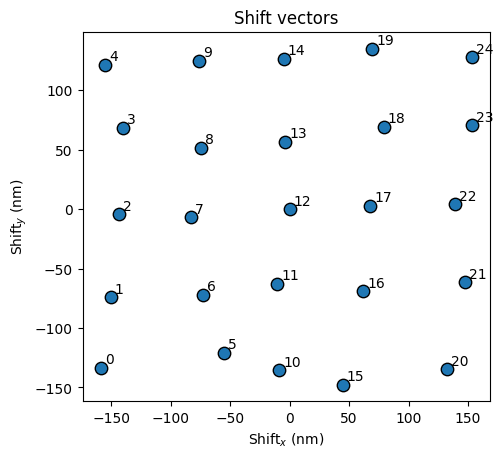

Reassigning time bins: 100%|██████████| 91/91 [02:35<00:00,  1.71s/it]

APR complete — data_input shape: (1, 1, 801, 801, 91, 25)


In [7]:
if DO_APR:

    # Select the first rep and z-plane -> (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Collapse time bins to get the intensity image (y, x, channels),
    # used only for shift-vector estimation (time-independent operation)
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors between each channel and the reference detector 
    # Returns: shift_vectors (n_channels, 2) — one (dy, dx) pair per channel [pixels]
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    # Convert shift vectors to nanometres for display
    pixel_size_nm = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel:")
    print(shift_vectors_nm)
    
    # Visualise the shift vectors on a grid matching the SPAD array geometry
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Apply reassignment independently for each time bin and overwrite data_input
    n_x, n_y, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, x, y, t_bins, channels) to match the original shape
    data_input = reassigned[np.newaxis, np.newaxis, ...]   # overwrite in memory
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")





In [8]:
if DO_APR:
    if FILENAME_OUTPUT is not None:
        apr_common_attrs = {
            "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
            "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
            "source_metadata_path": "/raw/metadata",
            "source_axes_path": "/raw/axes",
            "time_axis_source": "/raw/axes/digital_time_ns",
            "time_bin_ns": laser_period_ns / nbin,
            "laser_frequency_mhz": laser_freq_mhz,
            "laser_period_ns": laser_period_ns,
        }
        apr_summed = data_input.sum(axis=-1)
        target_path, output_run_id = write_h5_output_run(
            FILENAME_OUTPUT,
            "apr_001",
            [
                H5OutputProduct(
                    "apr",
                    data_input,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_spad_detector_counts",
                        "axis_order": "repetition,z,y,x,time_bin,detector_channel",
                    },
                ),
                H5OutputProduct(
                    "apr_sum",
                    apr_summed,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_channel_summed_decay",
                        "axis_order": "repetition,z,y,x,time_bin",
                        "source_data_path": "/output/{run_id}/products/apr",
                    },
                )
            ],
            mode="append",
            output_path=None,
            output_key_overwrite=True,
            output_type="image_tool",
            tool_name="APR Reassignment",
            algorithm_name="adaptive_pixel_reassignment",
            parameters={
                "ref_channel": REF_CHANNEL,
                "usf": USF,
                "reassign_mode": REASSIGN_MODE,
                "roi_json": [] if ROI is None else list(ROI),
                "data_key": DATA_KEY,
                "calibration_product": CALIBRATION_PRODUCT,
            },
            metadata={
                **apr_common_attrs,
                "pixel_size_x_um": pixel_size_x_um,
                "pixel_dwell_time_us": pxdwelltime,
                "output_nrep": data_input.shape[0],
                "output_nz": data_input.shape[1],
                "output_ny": data_input.shape[2],
                "output_nx": data_input.shape[3],
                "output_time_bins": data_input.shape[-2],
                "apr_summed_path": "/output/{run_id}/products/apr_sum",
                "selected_channel_count": data_input.shape[-1],
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            axes=[
                H5OutputProduct("repetition_index", np.asarray([0.0]) if data_input.shape[0] == 1 else np.arange(data_input.shape[0], dtype=float), attrs={"axis": "repetition", "long_name": "repetition index", "units": "index"}),
                H5OutputProduct("time_ns", t, attrs={"axis": "time_bin", "long_name": "time", "units": "ns"}),
                H5OutputProduct("x_um", np.linspace(-pixel_size_x_um * (data_input.shape[3] - 1) / 2, pixel_size_x_um * (data_input.shape[3] - 1) / 2, data_input.shape[3]) if data_input.shape[3] > 1 else np.asarray([0.0]), attrs={"axis": "x", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "x position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[3] - 1) * pixel_size_x_um) if data_input.shape[3] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("y_um", np.linspace(-pixel_size_x_um * (data_input.shape[2] - 1) / 2, pixel_size_x_um * (data_input.shape[2] - 1) / 2, data_input.shape[2]) if data_input.shape[2] > 1 else np.asarray([0.0]), attrs={"axis": "y", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "y position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[2] - 1) * pixel_size_x_um) if data_input.shape[2] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("z_um", np.asarray([0.0]) if data_input.shape[1] == 1 else np.arange(data_input.shape[1], dtype=float), attrs={"axis": "z", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "z position", "offset_um": 0.0, "pixel_size_um": 0.0, "range_um": 0.0, "units": "um"}),
            ],
            attrs={
                **apr_common_attrs,
                "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
                "output_axis_order": "repetition,z,y,x,time_bin",
                "output_data_path": "/output/{run_id}/products/apr_sum",
                "all_channel_output_data_path": "/output/{run_id}/products/apr",
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            set_default=True,
            default_product="apr_sum",
            intermediates=[
                H5OutputProduct(
                    "shift_vectors",
                    shift_vectors,
                    attrs={
                        "axes": "detector_channel,shift_component",
                        "shift_components_json": ["dy", "dx"],
                        "units": "pixels",
                    },
                )
            ],
        )
        PIPELINE_H5 = target_path
        APR_OUTPUT_RUN_ID = output_run_id
        APR_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/apr_sum"
        APR_SUMMED_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/apr_sum"
        print(f"Saved {output_run_id} -> {target_path}")
        print(f"Default output key: /output/{output_run_id}/products/apr_sum (summed decay); all-channel APR: /output/{output_run_id}/products/apr.")
    else:
        PIPELINE_H5 = FILENAME_OUTPUT
        APR_OUTPUT_RUN_ID = ""
        APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
        APR_SUMMED_OUTPUT_DATA_PATH = ""
        print("Export skipped (FILENAME_OUTPUT = None).")
else:
    PIPELINE_H5 = FILENAME_OUTPUT
    APR_OUTPUT_RUN_ID = ""
    APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
    APR_SUMMED_OUTPUT_DATA_PATH = ""
    print("APR skipped (DO_APR = False)")


Saved apr_001 -> /mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_apr.h5
Default output key: /output/apr_001/products/apr_sum (summed decay); all-channel APR: /output/apr_001/products/apr.


## APR — Before / After Intensity Comparison

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.
Both images are displayed with a physical scale bar and a calibrated colour scale
(counts per pixel dwell time).

**What to expect:**
- The APR image should appear sharper than the raw (finer features better resolved).
- The total intensity should be conserved; a small loss at the borders is normal
  (photons shifted outside the field of view are discarded by the interpolation).


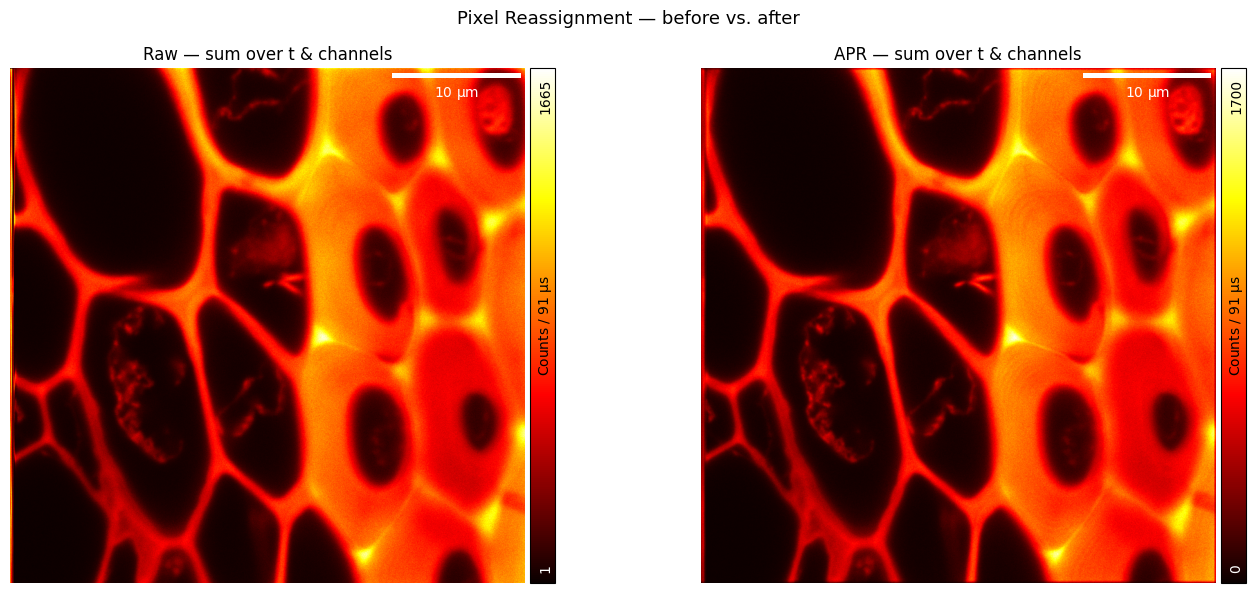

Raw image — min: 1  max: 1665
APR image — min: 0.0  max: 1700.0
Total counts — Raw: 259391071  APR: 264104704
Intensity conservation: 101.82% of raw counts retained


In [9]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → 2-D intensity map (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Use ShowImg to display images with a physical scale bar and calibrated colour scale,
    # matching the format used throughout the rest of the pipeline.
    gr.ShowImg(intensity_raw, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[0])
    axes[0].set_title("Raw — sum over t & channels")

    gr.ShowImg(intensity_apr, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[1])
    axes[1].set_title("APR — sum over t & channels")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
    print(f"Total counts — Raw: {intensity_raw.sum():.0f}  APR: {intensity_apr.sum():.0f}")
    print(f"Intensity conservation: {100 * intensity_apr.sum() / intensity_raw.sum():.2f}% of raw counts retained")

else:
    print("DO_APR = False — skipping before/after comparison.")

(<Figure size 640x480 with 2 Axes>, <Axes: >)

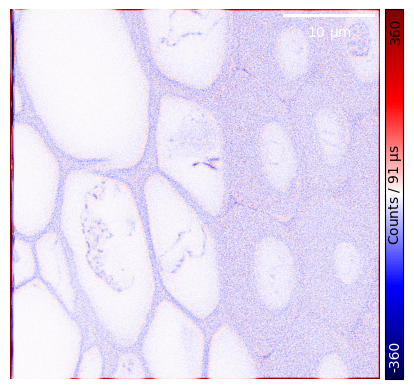

In [10]:

ddd=intensity_raw-intensity_apr
max_val = max(abs(np.percentile(ddd, 0.5)), abs(np.percentile(ddd, 99.5)))
gr.ShowImg(ddd, pixel_size_x_um, pxdwelltime, vmin=-max_val, vmax=max_val, cmap="seismic")



In [11]:
_ = show_h5_structure_html(FILENAME_OUTPUT)


In [12]:
FILENAME_OUTPUT

'/mnt/DATA/Mixed Data/NEW/Convallaria/convallaria_1us_bis_apr.h5'